### mini-BERT 프로젝트 요약
#### 참고 1차 실험 내용
https://github.com/wide-bridge/AIFFEL_quest_eng/blob/main/NLP/NLP03/mini-BERT.ipynb
#### 2차 프로젝트 요약
- 본 프로젝트는 BERT의 pretraining 구조를 기반으로 vocab size 8000과 약 1M 규모의 mini-BERT 모델을 직접 구현하고 학습하는 것을 목표로 하였다.
- 한국어 나무위키 코퍼스를 기반으로 SentencePiece 토크나이저를 구성하고, 
- 이를 이용하여 BERT pretraining에 필요한 MLM(Masked Language Model)과 NSP(Next Sentence Prediction) 데이터셋을 생성하였다.
- 데이터 전처리 과정에서는 전체 토큰의 약 15%를 마스킹하고, 그 중 80%는 [MASK], 10%는 랜덤 토큰, 10%는 원래 토큰을 유지하는 방식으로 MLM 학습 데이터를 구성하였다.
- 또한 두 문장을 짝지어 50% 확률로 실제 다음 문장과 랜덤 문장을 구성하여 NSP 학습 데이터를 생성하였다.
- 생성된 데이터셋은 대용량 데이터를 효율적으로 처리하기 위해 np.memmap 기반으로 저장하고 로드하는 방식을 적용하였다.
#### 1차 실험 대비 2차 실험에서 추가된 사항
- 1차 실험 대비 2차 실험에서는 모델 학습 및 평가 과정을 보다 체계적으로 구성하기 위해 다음과 같은 기능을 추가하였다.
- 데이터를 Train / Validation / Test 데이터셋으로 분리하여 학습 과정의 일반화 성능을 확인하도록 개선하였다.
- Epoch를 기존 10에서 최대 30까지 증가시키고, Early Stopping(Patience=5) 조건을 적용하여 validation loss가 더 이상 개선되지 않을 경우 학습을 종료하도록 하였다.
- Test Dataset을 별도로 구성하여 학습 완료 후 최종 성능 평가를 수행하였다.
- Transformer encoder 내부의 Attention Map을 시각화하여 모델이 문장에서 어떤 토큰에 집중하는지 확인하는 기능을 추가하였다.
- 학습이 완료된 mini-BERT 모델을 이용하여 실제 문장을 입력하여 MLM 및 NSP 추론을 수행하는 inference 기능을 구현하였다.
#### 모델 구조
- 본 프로젝트에서 구현한 mini-BERT 모델은 다음과 같은 특징을 가진다.
- Vocabulary Size : 8000
- Hidden Size : 128
- Encoder Layer : 4
- Attention Head : 4
- Feed Forward Dimension : 512
- Total Parameters : 약 1M (1,023,842)
- 이를 통해 기존 BERT 대비 매우 작은 경량 모델(mini-BERT) 구조를 구성하였다.
#### 학습 결과 요약
- 학습 결과 mini-BERT 모델은 다음과 같은 성능을 보였다.
- Best Epoch : 30
- Validation Loss : 4.7162
#### Train / Validation / Test 결과는 다음과 같다.
#### Train
- NSP Accuracy : 0.7139
- MLM Accuracy : 0.2752

#### Validation
- NSP Accuracy : 0.7108
- MLM Accuracy : 0.2964

#### Test
- NSP Accuracy : 0.7110
- MLM Accuracy : 0.2966
- 전체적으로 Train, Validation, Test 성능이 큰 차이를 보이지 않아 과도한 overfitting 없이 안정적으로 학습이 진행된 것으로 판단된다.

#### 추론 결과 분석
- 학습된 mini-BERT 모델을 이용하여 실제 문장에 대한 MLM 및 NSP 추론을 수행하였다.
- MLM 추론 결과에서는 일부 문장에서 문법적으로 가능한 후보 단어를 제시하였으나,
- 예를 들어 서울은 대한민국의 [MASK] 이다 와 같은 문장에서 “수도”와 같은 의미적으로 적절한 단어를 정확히 예측하지 못하는 경우도 관찰되었다.
- 또한 NSP 추론에서는 의미적으로 이어지는 문장 쌍에 대해서도 NotNext로 예측되는 경우가 확인되었다.
- 이는 mini-BERT가 제한된 파라미터 규모(약 1M)로 학습되었기 때문에 문장 간 의미 관계나 상식적인 문맥 이해 능력이 충분히 학습되지 않았을 가능성을 시사한다.

### 프로젝트 회고
- 이번 mini-BERT 프로젝트를 통해 다음과 같은 점을 확인할 수 있었다.
- Transformer 기반 언어 모델의 학습 과정은 데이터 전처리, 토크나이저 구성, 모델 구조 설계, 학습 파이프라인 구현이 긴밀하게 연결되어 있음을 이해할 수 있었다.
- BERT의 pretraining 과정에서 MLM과 NSP 데이터 생성 방식이 모델 학습 품질에 큰 영향을 미친다는 점을 확인하였다.
- 또한 모델의 파라미터 수가 매우 제한된 mini-BERT 구조에서는 기본적인 언어 패턴은 학습할 수 있으나, 
- 정교한 문맥 이해 능력에는 한계가 존재한다는 점을 직접 실험을 통해 확인할 수 있었다.
- Attention Map을 시각화함으로써 Transformer 모델이 문장에서 어떤 토큰에 집중하며 예측을 수행하는지 확인할 수 있었으며, 
- 이는 모델 해석 가능성을 이해하는 데 도움이 되었다.
- 마지막으로 학습된 모델을 이용하여 실제 문장에 대해 MLM 및 NSP 추론을 수행함으로써 BERT pretraining 모델의 실제 동작을 직접 확인할 수 있었다.

### Step 0. 환경 설정 및 프로젝트 경로 준비
- 필요한 라이브러리 설치
- 기본 import
- seed 고정
- device 확인
- 기존 data / models 폴더 및 파일 경로 연결
- 한글 폰트 설정

In [2]:
# ============================================================
# [STEP 0 - CELL 1] 기본 import / seed 고정 / device / 경로 준비
# - 기존 data, models 폴더를 그대로 사용합니다.
# - 새로 저장하는 파일명은 모두 mini_ 접두사를 사용합니다.
# ============================================================

from __future__ import absolute_import, division, print_function, unicode_literals

import os
import gc
import re
import math
import json
import copy
import random
import zipfile
import collections
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import sentencepiece as spm
from torchinfo import summary


# ------------------------------------------------------------
# seed 고정
# ------------------------------------------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)


# ------------------------------------------------------------
# device 설정
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


# ------------------------------------------------------------
# 폴더 준비
# ------------------------------------------------------------
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)


# ------------------------------------------------------------
# 한글 폰트 설정
# ------------------------------------------------------------
def setup_korean_font():
    candidates = [
        "C:/Windows/Fonts/malgun.ttf",
        "C:/Windows/Fonts/NanumGothic.ttf",
        "C:/Windows/Fonts/nanumgothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/System/Library/Fonts/AppleGothic.ttf",
    ]
    for path in candidates:
        if os.path.exists(path):
            font_prop = fm.FontProperties(fname=path)
            plt.rcParams["font.family"] = font_prop.get_name()
            plt.rcParams["axes.unicode_minus"] = False
            print("font loaded:", path)
            return
    print("한글 폰트를 찾지 못했습니다. 기본 폰트를 사용합니다.")

setup_korean_font()


# ------------------------------------------------------------
# 파일 경로
# ------------------------------------------------------------
SPM_PREFIX = "models/mini_ko_8000"
SPM_MODEL_PATH = f"{SPM_PREFIX}.model"
SPM_VOCAB_PATH = f"{SPM_PREFIX}.vocab"

PRETRAIN_JSON_PATH = "data/mini_bert_pre_train.json"
MEMMAP_INFO_PATH = "data/mini_pretrain_memmap_info.json"
SPLIT_INDEX_PATH = "data/mini_split_indices.npz"

MINI_CONFIG_PATH = "models/mini_bert_config.json"
MINI_HISTORY_PATH = "models/mini_bert_history.json"
MINI_BEST_MODEL_PATH = "models/mini_bert_best.pt"
MINI_LAST_MODEL_PATH = "models/mini_bert_last.pt"


def get_checkpoint_path(epoch):
    return f"models/mini_bert_epoch_{epoch:02d}.pt"


# ------------------------------------------------------------
# 기존 kowiki.txt 경로 찾기
# ------------------------------------------------------------
candidate_corpus_paths = [
    "kowiki.txt",
    "data/kowiki.txt",
    str(Path.home() / "work" / "bert_pretrain" / "data" / "kowiki.txt"),
]

corpus_file = None
for p in candidate_corpus_paths:
    if os.path.exists(p):
        corpus_file = p
        break

if corpus_file is None:
    raise FileNotFoundError(
        "kowiki.txt를 찾지 못했습니다. 현재 폴더 또는 data 폴더 등에 파일이 있는지 확인해주세요."
    )

print("corpus_file:", corpus_file)
print("SPM_MODEL_PATH:", SPM_MODEL_PATH)
print("PRETRAIN_JSON_PATH:", PRETRAIN_JSON_PATH)

device: cuda
font loaded: C:/Windows/Fonts/malgun.ttf
corpus_file: kowiki.txt
SPM_MODEL_PATH: models/mini_ko_8000.model
PRETRAIN_JSON_PATH: data/mini_bert_pre_train.json


### Step 1. SentencePiece 토크나이저 준비
- vocab size 8000 설정
- BERT 특수 토큰 포함
- SentencePiece 모델 학습 또는 기존 모델 로드
- special token id 및 vocab 확인

In [4]:
# ============================================================
# [STEP 1 - CELL 1] SentencePiece 모델 생성 또는 로드
# - vocab_size=8000으로 mini-BERT용 tokenizer를 준비합니다.
# - BERT 주요 특수 토큰 7개를 포함합니다.
# - 기존 mini 모델이 있으면 재사용합니다.
# ============================================================

if not os.path.exists(SPM_MODEL_PATH):
    print("mini SentencePiece 모델이 없어서 새로 학습합니다.")

    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} "
        f"--model_prefix={SPM_PREFIX} "
        f"--vocab_size=8000 "
        f"--model_type=bpe "
        f"--max_sentence_length=999999 "
        f"--pad_id=0 --pad_piece=[PAD] "
        f"--unk_id=1 --unk_piece=[UNK] "
        f"--bos_id=2 --bos_piece=[BOS] "
        f"--eos_id=3 --eos_piece=[EOS] "
        f"--user_defined_symbols=[SEP],[CLS],[MASK]"
    )
    print("mini SentencePiece 학습 완료")
else:
    print("기존 mini SentencePiece 모델을 그대로 사용합니다.")


vocab = spm.SentencePieceProcessor()
vocab.load(SPM_MODEL_PATH)

print("vocab size:", vocab.get_piece_size())
for i in range(7):
    print(i, "->", vocab.id_to_piece(i))

기존 mini SentencePiece 모델을 그대로 사용합니다.
vocab size: 8000
0 -> [PAD]
1 -> [UNK]
2 -> [BOS]
3 -> [EOS]
4 -> [SEP]
5 -> [CLS]
6 -> [MASK]


In [6]:
# ============================================================
# [STEP 1 - CELL 2] 특수 토큰 ID와 random replacement용 vocab_list 준비
# - MLM에서 랜덤 토큰 치환에 사용할 vocab_list를 준비합니다.
# - 특수 토큰 7개는 제외합니다.
# ============================================================

PAD_ID  = vocab.piece_to_id("[PAD]")
UNK_ID  = vocab.piece_to_id("[UNK]")
BOS_ID  = vocab.piece_to_id("[BOS]")
EOS_ID  = vocab.piece_to_id("[EOS]")
SEP_ID  = vocab.piece_to_id("[SEP]")
CLS_ID  = vocab.piece_to_id("[CLS]")
MASK_ID = vocab.piece_to_id("[MASK]")

vocab_list = []
for idx in range(7, vocab.get_piece_size()):
    if not vocab.is_unknown(idx):
        vocab_list.append(vocab.id_to_piece(idx))

print("PAD_ID :", PAD_ID)
print("UNK_ID :", UNK_ID)
print("BOS_ID :", BOS_ID)
print("EOS_ID :", EOS_ID)
print("SEP_ID :", SEP_ID)
print("CLS_ID :", CLS_ID)
print("MASK_ID:", MASK_ID)
print("usable vocab size:", len(vocab_list))
print("sample vocab pieces:", vocab_list[:20])

PAD_ID : 0
UNK_ID : 1
BOS_ID : 2
EOS_ID : 3
SEP_ID : 4
CLS_ID : 5
MASK_ID: 6
usable vocab size: 7993
sample vocab pieces: ['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아']


### Step 2. MLM용 Mask 생성 함수 구현
- 전체 토큰의 약 15%를 masking 대상으로 설정
- 80% [MASK], 10% 랜덤 토큰, 10% 원본 유지 규칙 적용
- [CLS], [SEP] 등 special token 제외 처리
- 어절 단위 subword masking 반영

In [9]:
# ============================================================
# [STEP 2 - CELL 1] MLM용 MASK 생성 함수
# - 기존 코드의 함수 이름 create_pretrain_mask를 그대로 유지합니다.
# - 전체 토큰의 약 15%를 대상으로,
#   80% [MASK], 10% random token, 10% 원본 유지 규칙을 적용합니다.
# - [CLS], [SEP]는 마스킹 대상에서 제외합니다.
# ============================================================

def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token index
    :return mask_label: mask된 token의 원래 값
    """
    cand_idx = []

    # 띄어쓰기 단위로 mask하기 위해서 index 분할
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue

        # SentencePiece 특성상 ▁로 시작하지 않으면 이전 token과 같은 어절의 subword로 처리
        if 0 < len(cand_idx) and not token.startswith("\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 index 순서를 섞음
    random.shuffle(cand_idx)

    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break

        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        for index in index_set:
            dice = random.random()

            # 80%는 [MASK]
            if dice < 0.8:
                masked_token = "[MASK]"
            # 10%는 random token
            elif dice < 0.9:
                masked_token = random.choice(vocab_list)
            # 10%는 원래 token 유지
            else:
                masked_token = tokens[index]

            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

### Step 3. NSP Pair 생성 및 시퀀스 구성
- 문장 A/B pair 생성
- 50% 실제 다음 문장, 50% 랜덤 문장 구성
- [CLS] A [SEP] B [SEP] 입력 시퀀스 생성
- segment id 생성
- 최대 길이에 맞게 시퀀스 trimming

In [16]:
# ============================================================
# [STEP 3 - CELL 1] 두 문장 길이 조정 함수
# - 기존 코드의 trim_tokens 함수를 그대로 유지합니다.
# - [CLS], [SEP], [SEP]를 포함하기 전에 두 문장의 전체 길이를 제한합니다.
# ============================================================

def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [18]:
# ============================================================
# [STEP 3 - CELL 2] NSP + MLM pretrain instance 생성 함수
# - 기존 코드의 create_pretrain_instances 함수를 그대로 유지합니다.
# - 50%는 실제 다음 문장(is_next=1), 50%는 랜덤 문장(is_next=0)입니다.
# - [CLS] A [SEP] B [SEP] 구조와 segment를 함께 생성합니다.
# ============================================================

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    :param vocab: vocab
    :param doc: doc list
    :param n_seq: max sequence length
    :param mask_prob: mask 비율
    :param vocab_list: random replacement용 vocab list
    """
    max_seq = n_seq - 3  # [CLS], [SEP], [SEP] 고려

    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            is_next = 0

            # 50% 확률로 실제 다음 문장 사용
            if len(current_chunk) > 1 and random.random() >= 0.5:
                is_next = 1
                for j in range(a_end, len(current_chunk)):
                    tokens_b.extend(current_chunk[j])
            else:
                # 50% 확률로 랜덤 문장 사용
                is_next = 0
                random_sent = random.choice(doc)
                tokens_b.extend(random_sent)

            trim_tokens(tokens_a, tokens_b, max_seq)

            if len(tokens_a) < 1 or len(tokens_b) < 1:
                current_chunk = []
                current_length = 0
                continue

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # 전체 token의 약 15%를 mask
            mask_cnt = max(1, int(round(len(tokens) * mask_prob)))
            tokens_masked, mask_idx, mask_label = create_pretrain_mask(copy.deepcopy(tokens), mask_cnt, vocab_list)

            instance = {
                "tokens": tokens_masked,
                "segment": segment,
                "is_next": int(is_next),
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0

    return instances

### Step 4. BERT Pretrain 데이터셋 생성 및 Train/Val/Test 분리
- pretrain json 데이터 생성
- MLM label, NSP label 포함
- np.memmap 기반 데이터 저장
- pretrain 데이터 로드
- train / val / test 분리 및 index 저장
- 분리된 입력과 라벨 구성

In [21]:
# ============================================================
# [STEP 4 - CELL 1] pretrain json 생성 함수
# - 기존 코드의 make_pretrain_data 함수를 그대로 유지합니다.
# - 문서 단위로 읽어서 mini_bert_pre_train.json을 생성합니다.
# ============================================================

def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """
    pretrain 데이터 생성
    :param vocab: vocab
    :param in_file: input corpus file
    :param out_file: output jsonl file
    :param n_seq: max sequence length
    :param mask_prob: MLM mask 비율
    """

    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    vocab_list = []
    for idx in range(7, vocab.get_piece_size()):
        if not vocab.is_unknown(idx):
            vocab_list.append(vocab.id_to_piece(idx))

    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as in_f:
        for _ in in_f:
            line_cnt += 1

    with open(out_file, "w", encoding="utf-8") as out_f:
        with open(in_file, "r", encoding="utf-8") as in_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt, desc="make_pretrain_data"):
                line = line.strip()

                if line == "":
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:
                    pieces = vocab.encode_as_pieces(line)
                    if len(pieces) > 0:
                        doc.append(pieces)

            if 0 < len(doc):
                save_pretrain_instances(out_f, doc)

    print("pretrain json saved to:", out_file)

In [23]:
# ============================================================
# [STEP 4 - CELL 2] mini pretrain json 생성
# - 이미 생성된 mini pretrain json이 있으면 그대로 사용합니다.
# ============================================================

N_SEQ = 128
MASK_PROB = 0.15

if not os.path.exists(PRETRAIN_JSON_PATH):
    make_pretrain_data(vocab, corpus_file, PRETRAIN_JSON_PATH, N_SEQ, mask_prob=MASK_PROB)
else:
    print("기존 mini pretrain json을 그대로 사용합니다:", PRETRAIN_JSON_PATH)

total_json_lines = 0
with open(PRETRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    for _ in f:
        total_json_lines += 1

print("total pretrain instances:", total_json_lines)

기존 mini pretrain json을 그대로 사용합니다: data/mini_bert_pre_train.json
total pretrain instances: 918198


In [24]:
# ============================================================
# [STEP 4 - CELL 3] pretrain json -> memmap 변환 함수
# - 메모리를 절약하기 위해 np.memmap 형식으로 저장합니다.
# - input_ids, segment_ids, NSP label, MLM label을 만듭니다.
# ============================================================

def build_pretrain_memmap(vocab, json_path, n_seq, info_path):
    with open(json_path, "r", encoding="utf-8") as f:
        total = sum(1 for _ in f)

    enc_path = "data/mini_enc_tokens.memmap"
    seg_path = "data/mini_segments.memmap"
    nsp_path = "data/mini_labels_nsp.memmap"
    mlm_path = "data/mini_labels_mlm.memmap"

    enc_tokens = np.memmap(enc_path, mode="w+", dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(seg_path, mode="w+", dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(nsp_path, mode="w+", dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(mlm_path, mode="w+", dtype=np.int32, shape=(total, n_seq))

    with open(json_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total, desc="build_pretrain_memmap")):
            data = json.loads(line)

            # token id
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [PAD_ID] * (n_seq - len(enc_token))

            # segment id
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))

            # NSP label
            label_nsp = int(data["is_next"])

            # MLM label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, fill_value=PAD_ID, dtype=np.int32)
            label_mlm[mask_idx] = mask_label

            enc_tokens[i] = np.array(enc_token, dtype=np.int32)
            segments[i] = np.array(segment, dtype=np.int32)
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    enc_tokens.flush()
    segments.flush()
    labels_nsp.flush()
    labels_mlm.flush()

    info = {
        "total": total,
        "n_seq": n_seq,
        "enc_path": enc_path,
        "seg_path": seg_path,
        "nsp_path": nsp_path,
        "mlm_path": mlm_path,
        "dtype": "int32"
    }

    with open(info_path, "w", encoding="utf-8") as f:
        json.dump(info, f, ensure_ascii=False, indent=2)

    print("memmap info saved to:", info_path)
    return info

In [25]:
# ============================================================
# [STEP 4 - CELL 4] memmap 생성 또는 로드
# - 이미 mini memmap 정보 파일이 있으면 그대로 사용합니다.
# ============================================================

if not os.path.exists(MEMMAP_INFO_PATH):
    memmap_info = build_pretrain_memmap(vocab, PRETRAIN_JSON_PATH, N_SEQ, MEMMAP_INFO_PATH)
else:
    with open(MEMMAP_INFO_PATH, "r", encoding="utf-8") as f:
        memmap_info = json.load(f)
    print("기존 mini memmap 정보를 그대로 사용합니다.")

print(memmap_info)

기존 mini memmap 정보를 그대로 사용합니다.
{'total': 918198, 'n_seq': 128, 'enc_path': 'data/mini_enc_tokens.memmap', 'seg_path': 'data/mini_segments.memmap', 'nsp_path': 'data/mini_labels_nsp.memmap', 'mlm_path': 'data/mini_labels_mlm.memmap', 'dtype': 'int32'}


In [26]:
# ============================================================
# [STEP 4 - CELL 5] pretrain 데이터 로드 함수
# - 기존 코드의 load_pre_train_data 함수를 그대로 유지합니다.
# - memmap을 읽어 numpy array로 반환합니다.
# ============================================================

def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    pretrain 데이터 로드
    :param vocab: vocab
    :param filename: memmap info json file
    :param n_seq: sequence length
    :param count: 사용할 데이터 수 (None이면 전체)
    :return (enc_tokens, segments), (labels_nsp, labels_mlm)
    """
    with open(filename, "r", encoding="utf-8") as f:
        info = json.load(f)

    total = info["total"]
    use_count = total if count is None else min(count, total)

    enc_tokens = np.memmap(info["enc_path"], mode="r", dtype=np.int32, shape=(total, n_seq))[:use_count]
    segments = np.memmap(info["seg_path"], mode="r", dtype=np.int32, shape=(total, n_seq))[:use_count]
    labels_nsp = np.memmap(info["nsp_path"], mode="r", dtype=np.int32, shape=(total,))[:use_count]
    labels_mlm = np.memmap(info["mlm_path"], mode="r", dtype=np.int32, shape=(total, n_seq))[:use_count]

    enc_tokens = np.array(enc_tokens, dtype=np.int64)
    segments = np.array(segments, dtype=np.int64)
    labels_nsp = np.array(labels_nsp, dtype=np.int64)
    labels_mlm = np.array(labels_mlm, dtype=np.int64)

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [27]:
# ============================================================
# [STEP 4 - CELL 6] 전체 pretrain 데이터 로드
# - 최종 제출에서는 count=None으로 전체 데이터를 사용합니다.
# - 처음 점검만 할 때는 count를 줄여도 됩니다.
# ============================================================

pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab=vocab,
    filename=MEMMAP_INFO_PATH,
    n_seq=N_SEQ,
    count=None
)

print("enc_tokens shape:", pre_train_inputs[0].shape)
print("segments shape  :", pre_train_inputs[1].shape)
print("labels_nsp shape:", pre_train_labels[0].shape)
print("labels_mlm shape:", pre_train_labels[1].shape)

enc_tokens shape: (918198, 128)
segments shape  : (918198, 128)
labels_nsp shape: (918198,)
labels_mlm shape: (918198, 128)


In [32]:
# ============================================================
# [STEP 4 - CELL 7] train / val / test 분리
# - 기존 코드에는 분리가 없었기 때문에 여기서 명확하게 추가합니다.
# - 80 / 10 / 10 비율로 분리합니다.
# - split index는 mini_split_indices.npz로 저장합니다.
# ============================================================

total_count = len(pre_train_inputs[0])
all_indices = np.arange(total_count)

if not os.path.exists(SPLIT_INDEX_PATH):
    train_idx, temp_idx = train_test_split(
        all_indices,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.5,
        random_state=42,
        shuffle=True
    )

    np.savez(
        SPLIT_INDEX_PATH,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx
    )
    print("split indices saved:", SPLIT_INDEX_PATH)
else:
    split_data = np.load(SPLIT_INDEX_PATH)
    train_idx = split_data["train_idx"]
    val_idx = split_data["val_idx"]
    test_idx = split_data["test_idx"]
    print("기존 split indices를 그대로 사용합니다.")

print("train:", len(train_idx))
print("val  :", len(val_idx))
print("test :", len(test_idx))

split indices saved: data/mini_split_indices.npz
train: 734558
val  : 91820
test : 91820


In [37]:
# ============================================================
# [STEP 4 - CELL 8] split 결과를 실제 배열로 분리
# - train / val / test 입력과 라벨을 각각 나눕니다.
# ============================================================

train_inputs = (
    pre_train_inputs[0][train_idx],
    pre_train_inputs[1][train_idx]
)
train_labels = (
    pre_train_labels[0][train_idx],
    pre_train_labels[1][train_idx]
)

val_inputs = (
    pre_train_inputs[0][val_idx],
    pre_train_inputs[1][val_idx]
)
val_labels = (
    pre_train_labels[0][val_idx],
    pre_train_labels[1][val_idx]
)

test_inputs = (
    pre_train_inputs[0][test_idx],
    pre_train_inputs[1][test_idx]
)
test_labels = (
    pre_train_labels[0][test_idx],
    pre_train_labels[1][test_idx]
)

print("train enc shape:", train_inputs[0].shape)
print("val   enc shape:", val_inputs[0].shape)
print("test  enc shape:", test_inputs[0].shape)

train enc shape: (734558, 128)
val   enc shape: (91820, 128)
test  enc shape: (91820, 128)


### Step 5. BERT 학습 공통 유틸리티 정의
- pad mask 함수 정의
- ahead mask 함수 정의
- GELU activation 함수 정의
- parameter initializer 함수 정의
- Config 클래스 정의

In [39]:
# ============================================================
# [STEP 5 - CELL 1] pad mask / ahead mask 정의
# - 기존 코드의 함수 이름을 그대로 유지합니다.
# - BERT는 encoder-only 구조라 주로 pad mask를 사용합니다.
# ============================================================

def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: attention mask
    """
    mask = tokens.eq(i_pad).unsqueeze(1).unsqueeze(2)  # (bs, 1, 1, n_seq)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: attention에서 미래 토큰을 가리는 mask
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq), device=tokens.device))
    ahead_mask = ahead_mask.bool().unsqueeze(0).unsqueeze(1)
    pad_mask = get_pad_mask(tokens, i_pad)
    return ahead_mask | pad_mask

In [41]:
# ============================================================
# [STEP 5 - CELL 2] GELU 활성화 함수
# - 기존 코드의 gelu 함수를 그대로 유지합니다.
# ============================================================

def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

In [43]:
# ============================================================
# [STEP 5 - CELL 3] parameter initializer 함수
# - 기존 코드의 kernel_initializer, bias_initializer를 그대로 유지합니다.
# ============================================================

def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 표준편차
    """
    return torch.nn.init.trunc_normal_


def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

In [45]:
# ============================================================
# [STEP 5 - CELL 4] Config 클래스
# - 기존 코드의 Config(dict) 구조를 그대로 유지합니다.
# - json을 config 형태로 로드하기 위한 용도입니다.
# ============================================================

class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r', encoding='utf-8') as f:
            config = json.loads(f.read())
            return Config(config)

### Step 6. mini-BERT 모델 구현 및 파라미터 확인
- mini-BERT config 저장 및 로드
- SharedEmbedding 구현
- PositionEmbedding 구현
- Scale Dot Product Attention 구현
- Multi-Head Attention 구현
- Position-wise Feed Forward 구현
- Encoder Layer 구현
- BERT 본체 구현
- NSP 분류 헤드 및 PreTrainModel 구현
- 전체 파라미터 수 확인

In [47]:
# ============================================================
# [STEP 6 - CELL 1] mini-BERT config 저장
# - 약 1M 전후 파라미터가 되도록 설정합니다.
# - vocab_size는 8000 tokenizer와 맞춥니다.
# ============================================================

mini_config = {
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,
    "dropout": 0.1,
    "d_ff": 192,
    "layernorm_epsilon": 1e-12,
    "n_layer": 3,
    "n_seq": N_SEQ,
    "n_vocab": vocab.get_piece_size(),
    "i_pad": PAD_ID
}

with open(MINI_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(mini_config, f, ensure_ascii=False, indent=2)

config = Config.load(MINI_CONFIG_PATH)
print(config)

{'d_model': 96, 'n_head': 4, 'd_head': 24, 'dropout': 0.1, 'd_ff': 192, 'layernorm_epsilon': 1e-12, 'n_layer': 3, 'n_seq': 128, 'n_vocab': 8000, 'i_pad': 0}


In [49]:
# ============================================================
# [STEP 6 - CELL 2] SharedEmbedding 클래스
# - 기존 코드의 SharedEmbedding 클래스 이름을 그대로 유지합니다.
# - token embedding과 MLM output projection에 공유 가중치를 사용합니다.
# ============================================================

class SharedEmbedding(nn.Module):
    """
    Weight Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return F.embedding(inputs, self.shared_weights)
        elif mode == "linear":
            return torch.matmul(inputs, self.shared_weights.t())
        else:
            raise ValueError("mode should be 'embedding' or 'linear'")

In [51]:
# ============================================================
# [STEP 6 - CELL 3] PositionEmbedding 클래스
# - 기존 코드의 PositionEmbedding 클래스 이름을 그대로 유지합니다.
# ============================================================

class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        batch_size, seq_len = inputs.size()
        positions = torch.arange(seq_len, device=inputs.device).unsqueeze(0).expand(batch_size, seq_len)
        return self.embedding(positions)

In [53]:
# ============================================================
# [STEP 6 - CELL 4] Scale Dot Product Attention 클래스
# - 기존 코드의 ScaleDotProductAttention 클래스 이름을 그대로 유지합니다.
# - attention map 시각화를 위해 마지막 attention 확률을 저장합니다.
# ============================================================

class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()
        self.last_attn_prob = None

    def forward(self, Q, K, V, attn_mask):
        d_head = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(d_head)

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask, -1e9)

        attn_prob = F.softmax(scores, dim=-1)
        self.last_attn_prob = attn_prob.detach()

        attn_out = torch.matmul(attn_prob, V)
        return attn_out

In [55]:
# ============================================================
# [STEP 6 - CELL 5] MultiHeadAttention 클래스
# - 기존 코드의 MultiHeadAttention 클래스 이름을 그대로 유지합니다.
# - attention map 시각화를 위해 마지막 head attention을 저장합니다.
# ============================================================

class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.linear = nn.Linear(config.n_head * config.d_head, config.d_model)

        self.attention = ScaleDotProductAttention()
        self.dropout = nn.Dropout(config.dropout)
        self.last_attn_prob = None

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.size(0)

        q_s = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        k_s = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        v_s = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        if attn_mask is not None:
            attn_mask = attn_mask.expand(batch_size, self.n_head, Q.size(1), K.size(1))

        attn_out = self.attention(q_s, k_s, v_s, attn_mask)
        self.last_attn_prob = self.attention.last_attn_prob

        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, -1, self.n_head * self.d_head)
        output = self.linear(attn_out)
        return self.dropout(output)

In [57]:
# ============================================================
# [STEP 6 - CELL 6] PositionWiseFeedForward 클래스
# - 기존 코드의 PositionWiseFeedForward 클래스 이름을 그대로 유지합니다.
# ============================================================

class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, inputs):
        ff_val = self.W_2(self.dropout(gelu(self.W_1(inputs))))
        return ff_val

In [59]:
# ============================================================
# [STEP 6 - CELL 7] EncoderLayer 클래스
# - 기존 코드의 EncoderLayer 클래스 이름을 그대로 유지합니다.
# ============================================================

class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

In [61]:
# ============================================================
# [STEP 6 - CELL 8] BERT 클래스
# - 기존 코드의 BERT 클래스 이름을 그대로 유지합니다.
# - token / position / segment embedding을 합친 뒤 encoder stack을 통과시킵니다.
# ============================================================

class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)]
        )

        self.pooler = nn.Linear(config.d_model, config.d_model)

    def get_embedding(self, enc_tokens, segments):
        token_emb = self.embedding(enc_tokens, mode="embedding")
        pos_emb = self.position(enc_tokens)
        seg_emb = self.segment(segments)
        return self.norm(token_emb + pos_emb + seg_emb)

    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = torch.tanh(self.pooler(enc_out[:, 0]))
        logits_lm = self.embedding(enc_out, mode="linear")

        return logits_cls, logits_lm

In [63]:
# ============================================================
# [STEP 6 - CELL 9] NSP 분류 헤드와 PreTrainModel
# - 기존 코드의 PooledOutput, PreTrainModel, build_model_pre_train을 그대로 유지합니다.
# ============================================================

class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output)

    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs


class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        outputs_nsp = self.pooled_output(logits_cls)
        outputs_mlm = logits_lm
        return outputs_nsp, outputs_mlm


def build_model_pre_train(config):
    return PreTrainModel(config)

In [65]:
# ============================================================
# [STEP 6 - CELL 10] mini-BERT 모델 생성 및 파라미터 수 확인
# - 약 1M 전후 규모인지 확인합니다.
# - 제출 루브릭 대응을 위해 파라미터 수를 출력합니다.
# ============================================================

pre_train_model = build_model_pre_train(config).to(device)

total_params = sum(p.numel() for p in pre_train_model.parameters())
trainable_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)

print(f"total params    : {total_params:,}")
print(f"trainable params: {trainable_params:,}")

enc_tokens_example = torch.randint(0, config.n_vocab, (2, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (2, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, input_data=[enc_tokens_example, segments_example], depth=3)

total params    : 1,023,842
trainable params: 1,023,842


Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [2, 2]                    --
├─BERT: 1-1                                                  [2, 96]                   --
│    └─SharedEmbedding: 2-1                                  [2, 128, 96]              768,000
│    └─PositionEmbedding: 2-2                                [2, 128, 96]              --
│    │    └─Embedding: 3-1                                   [2, 128, 96]              12,288
│    └─Embedding: 2-3                                        [2, 128, 96]              192
│    └─LayerNorm: 2-4                                        [2, 128, 96]              192
│    └─Dropout: 2-5                                          [2, 128, 96]              --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [2, 128, 96]           

### Step 7. Loss, Accuracy, DataLoader 구성
- MLM loss 함수 정의
- MLM accuracy 함수 정의
- cosine learning rate scheduler 정의
- train / val / test tensor 변환
- train / val / test DataLoader 생성

In [67]:
# ============================================================
# [STEP 7 - CELL 1] MLM loss 함수
# - 기존 코드의 lm_loss 함수를 그대로 유지합니다.
# - PAD가 아닌 MLM 정답 위치만 loss 계산에 반영합니다.
# ============================================================

def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    loss = F.cross_entropy(
        y_pred.view(-1, y_pred.size(-1)),
        y_true.view(-1),
        reduction='none'
    )

    mask = (y_true != PAD_ID).float().view(-1)
    loss = loss * mask

    return loss.sum() / mask.sum().clamp(min=1.0)

In [69]:
# ============================================================
# [STEP 7 - CELL 2] MLM accuracy 함수
# - 기존 코드의 lm_acc 함수를 그대로 유지합니다.
# - PAD가 아닌 MLM 정답 위치만 정확도 계산에 반영합니다.
# ============================================================

def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    y_pred_class = torch.argmax(y_pred, dim=-1)
    matches = (y_true == y_pred_class).float()

    mask = (y_true != PAD_ID).float()
    matches *= mask

    accuracy = matches.sum() / mask.sum().clamp(min=1.0)
    return accuracy

In [71]:
# ============================================================
# [STEP 7 - CELL 3] Cosine learning rate scheduler
# - 기존 코드의 CosineSchedule 클래스를 그대로 유지합니다.
# ============================================================

class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / max(1, self.warmup_steps)) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group["lr"] = lr
        return lr

In [73]:
# ============================================================
# [STEP 7 - CELL 4] numpy -> torch tensor 변환 함수
# - train / val / test 데이터를 각각 TensorDataset으로 만들기 위한 준비 단계입니다.
# ============================================================

def to_torch_tensors(inputs, labels):
    input_0 = torch.tensor(inputs[0], dtype=torch.long)
    input_1 = torch.tensor(inputs[1], dtype=torch.long)
    label_0 = torch.tensor(labels[0], dtype=torch.long)
    label_1 = torch.tensor(labels[1], dtype=torch.long)
    return [input_0, input_1], [label_0, label_1]


train_inputs_t, train_labels_t = to_torch_tensors(train_inputs, train_labels)
val_inputs_t, val_labels_t = to_torch_tensors(val_inputs, val_labels)
test_inputs_t, test_labels_t = to_torch_tensors(test_inputs, test_labels)

print("torch train tensor shape:", train_inputs_t[0].shape)
print("torch val tensor shape  :", val_inputs_t[0].shape)
print("torch test tensor shape :", test_inputs_t[0].shape)

torch train tensor shape: torch.Size([734558, 128])
torch val tensor shape  : torch.Size([91820, 128])
torch test tensor shape : torch.Size([91820, 128])


In [75]:
# ============================================================
# [STEP 7 - CELL 5] DataLoader 생성
# - train / val / test 각각의 DataLoader를 만듭니다.
# - 기존 코드에는 train_dataloader만 있었지만 여기서는 세 개를 명확히 만듭니다.
# ============================================================

BATCH_SIZE = 64

train_dataset = TensorDataset(
    train_inputs_t[0], train_inputs_t[1], train_labels_t[0], train_labels_t[1]
)
val_dataset = TensorDataset(
    val_inputs_t[0], val_inputs_t[1], val_labels_t[0], val_labels_t[1]
)
test_dataset = TensorDataset(
    test_inputs_t[0], test_inputs_t[1], test_labels_t[0], test_labels_t[1]
)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("train batches:", len(train_dataloader))
print("val batches  :", len(val_dataloader))
print("test batches :", len(test_dataloader))

train batches: 11478
val batches  : 1435
test batches : 1435


### Step 8. mini-BERT 학습 및 Early Stopping 적용
- optimizer, scheduler, early stopping 설정
- 1 epoch 학습 함수 정의
- validation / test 평가 함수 정의
- history 초기화
- train + validation 학습 수행
- val loss 기준 best model 저장
- early stopping 적용
- last model 및 history 저장

In [77]:
# ============================================================
# [STEP 8 - CELL 1] optimizer / scheduler / early stopping 설정
# - 기존 코드 흐름은 유지하면서 val loss 기준 early stopping을 추가합니다.
# ============================================================

EPOCHS = 30
BASE_LR = 5e-4
WEIGHT_DECAY = 0.01
PATIENCE = 5
MIN_DELTA = 1e-4

train_steps = len(train_dataloader) * EPOCHS
warmup_steps = max(100, train_steps // 10)

optimizer = optim.AdamW(pre_train_model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=warmup_steps,
    max_lr=BASE_LR
)

loss_fn_nsp = nn.CrossEntropyLoss()

print("train_steps :", train_steps)
print("warmup_steps:", warmup_steps)
print("BASE_LR     :", BASE_LR)
print("PATIENCE    :", PATIENCE)

train_steps : 344340
warmup_steps: 34434
BASE_LR     : 0.0005
PATIENCE    : 5


In [78]:
# ============================================================
# [STEP 8 - CELL 2] 1 epoch 학습 함수
# - train set에서 NSP + MLM을 동시에 학습합니다.
# - epoch 평균 loss / accuracy를 반환합니다.
# ============================================================

def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()

    total_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0

    pbar = tqdm(dataloader, desc="train", leave=False)

    for batch in pbar:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        enc_tokens_batch = enc_tokens_batch.to(device)
        segments_batch = segments_batch.to(device)
        labels_nsp_batch = labels_nsp_batch.to(device)
        labels_mlm_batch = labels_mlm_batch.to(device)

        optimizer.zero_grad()

        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm)
        loss = loss_nsp + loss_mlm

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        current_lr = scheduler.step()

        with torch.no_grad():
            nsp_pred = torch.argmax(logits_nsp, dim=-1)
            nsp_accuracy = (nsp_pred == labels_nsp_batch).float().mean()
            mlm_accuracy = lm_acc(labels_mlm_batch, logits_mlm)

        total_loss += loss.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()
        total_nsp_acc += nsp_accuracy.item()
        total_mlm_acc += mlm_accuracy.item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "nsp": f"{loss_nsp.item():.4f}",
            "mlm": f"{loss_mlm.item():.4f}",
            "nsp_acc": f"{nsp_accuracy.item():.4f}",
            "mlm_acc": f"{mlm_accuracy.item():.4f}",
            "lr": f"{current_lr:.6f}"
        })

    result = {
        "total_loss": total_loss / len(dataloader),
        "nsp_loss": total_nsp_loss / len(dataloader),
        "mlm_loss": total_mlm_loss / len(dataloader),
        "nsp_acc": total_nsp_acc / len(dataloader),
        "mlm_acc": total_mlm_acc / len(dataloader),
        "lr": current_lr
    }
    return result

In [81]:
# ============================================================
# [STEP 8 - CELL 3] validation / test 평가 함수
# - val과 test에서 같은 지표를 계산합니다.
# - early stopping과 최종 test 평가에 모두 사용합니다.
# ============================================================

def evaluate_pretrain(model, dataloader, device, desc="eval"):
    model.eval()

    total_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc=desc, leave=False)

        for batch in pbar:
            enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

            enc_tokens_batch = enc_tokens_batch.to(device)
            segments_batch = segments_batch.to(device)
            labels_nsp_batch = labels_nsp_batch.to(device)
            labels_mlm_batch = labels_mlm_batch.to(device)

            logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)

            loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
            loss_mlm = lm_loss(labels_mlm_batch, logits_mlm)
            loss = loss_nsp + loss_mlm

            nsp_pred = torch.argmax(logits_nsp, dim=-1)
            nsp_accuracy = (nsp_pred == labels_nsp_batch).float().mean()
            mlm_accuracy = lm_acc(labels_mlm_batch, logits_mlm)

            total_loss += loss.item()
            total_nsp_loss += loss_nsp.item()
            total_mlm_loss += loss_mlm.item()
            total_nsp_acc += nsp_accuracy.item()
            total_mlm_acc += mlm_accuracy.item()

    result = {
        "total_loss": total_loss / len(dataloader),
        "nsp_loss": total_nsp_loss / len(dataloader),
        "mlm_loss": total_mlm_loss / len(dataloader),
        "nsp_acc": total_nsp_acc / len(dataloader),
        "mlm_acc": total_mlm_acc / len(dataloader),
    }
    return result

In [83]:
# ============================================================
# [STEP 8 - CELL 4] history 초기화
# - train / val / test 성능을 모두 기록할 수 있도록 history를 확장합니다.
# ============================================================

history = {
    "train_total_loss": [],
    "train_nsp_loss": [],
    "train_mlm_loss": [],
    "train_nsp_acc": [],
    "train_mlm_acc": [],
    "val_total_loss": [],
    "val_nsp_loss": [],
    "val_mlm_loss": [],
    "val_nsp_acc": [],
    "val_mlm_acc": [],
    "lr": []
}

In [85]:
# ============================================================
# [STEP 8 - CELL 5] mini-BERT 학습 + early stopping
# - train과 val을 모두 돌립니다.
# - val_total_loss 기준으로 best model을 저장합니다.
# - mini_ 접두사로 checkpoint를 저장합니다.
# ============================================================

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0

pre_train_model.to(device)

for epoch in range(1, EPOCHS + 1):
    print(f"\n========== Epoch {epoch}/{EPOCHS} ==========")

    train_result = train_one_epoch(
        model=pre_train_model,
        dataloader=train_dataloader,
        optimizer=optimizer,
        scheduler=learning_rate_scheduler,
        device=device
    )

    val_result = evaluate_pretrain(
        model=pre_train_model,
        dataloader=val_dataloader,
        device=device,
        desc="val"
    )

    history["train_total_loss"].append(train_result["total_loss"])
    history["train_nsp_loss"].append(train_result["nsp_loss"])
    history["train_mlm_loss"].append(train_result["mlm_loss"])
    history["train_nsp_acc"].append(train_result["nsp_acc"])
    history["train_mlm_acc"].append(train_result["mlm_acc"])

    history["val_total_loss"].append(val_result["total_loss"])
    history["val_nsp_loss"].append(val_result["nsp_loss"])
    history["val_mlm_loss"].append(val_result["mlm_loss"])
    history["val_nsp_acc"].append(val_result["nsp_acc"])
    history["val_mlm_acc"].append(val_result["mlm_acc"])

    history["lr"].append(train_result["lr"])

    print(
        f"[TRAIN] total={train_result['total_loss']:.4f} | "
        f"nsp={train_result['nsp_loss']:.4f} | "
        f"mlm={train_result['mlm_loss']:.4f} | "
        f"nsp_acc={train_result['nsp_acc']:.4f} | "
        f"mlm_acc={train_result['mlm_acc']:.4f}"
    )
    print(
        f"[VAL]   total={val_result['total_loss']:.4f} | "
        f"nsp={val_result['nsp_loss']:.4f} | "
        f"mlm={val_result['mlm_loss']:.4f} | "
        f"nsp_acc={val_result['nsp_acc']:.4f} | "
        f"mlm_acc={val_result['mlm_acc']:.4f}"
    )

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": pre_train_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": dict(config),
        "history": history,
        "best_val_loss": best_val_loss,
        "total_params": total_params
    }

    torch.save(checkpoint, get_checkpoint_path(epoch))

    # best model 저장
    if val_result["total_loss"] < best_val_loss - MIN_DELTA:
        best_val_loss = val_result["total_loss"]
        best_epoch = epoch
        patience_counter = 0
        torch.save(checkpoint, MINI_BEST_MODEL_PATH)
        print(f"best model updated at epoch {epoch}")
    else:
        patience_counter += 1
        print(f"early stopping counter: {patience_counter}/{PATIENCE}")

    # 마지막 모델 저장
    torch.save(checkpoint, MINI_LAST_MODEL_PATH)

    # history 저장
    with open(MINI_HISTORY_PATH, "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

    # early stopping
    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}")
        break

print("\n학습 완료")
print("best_epoch   :", best_epoch)
print("best_val_loss:", best_val_loss)


========== Epoch 1/30 ==========


[TRAIN] total=8.2203 | nsp=0.6258 | mlm=7.5945 | nsp_acc=0.6216 | mlm_acc=0.0280
[VAL]   total=7.9394 | nsp=0.5917 | mlm=7.3477 | nsp_acc=0.6486 | mlm_acc=0.0311
best model updated at epoch 1

========== Epoch 2/30 ==========


[TRAIN] total=7.6510 | nsp=0.5826 | mlm=7.0683 | nsp_acc=0.6585 | mlm_acc=0.0474
[VAL]   total=7.0493 | nsp=0.5583 | mlm=6.4910 | nsp_acc=0.6818 | mlm_acc=0.0994
best model updated at epoch 2

========== Epoch 3/30 ==========


[TRAIN] total=6.4905 | nsp=0.5600 | mlm=5.9305 | nsp_acc=0.6829 | mlm_acc=0.1386
[VAL]   total=5.6874 | nsp=0.5444 | mlm=5.1430 | nsp_acc=0.6973 | mlm_acc=0.1957
best model updated at epoch 3

========== Epoch 4/30 ==========


[TRAIN] total=5.6637 | nsp=0.5494 | mlm=5.1143 | nsp_acc=0.6921 | mlm_acc=0.2011
[VAL]   total=5.2884 | nsp=0.5432 | mlm=4.7452 | nsp_acc=0.6955 | mlm_acc=0.2361
best model updated at epoch 4

========== Epoch 5/30 ==========


...

[TRAIN] total=4.8780 | nsp=0.5160 | mlm=4.3621 | nsp_acc=0.7130 | mlm_acc=0.2744
[VAL]   total=4.7181 | nsp=0.5215 | mlm=4.1965 | nsp_acc=0.7107 | mlm_acc=0.2959
best model updated at epoch 26

========== Epoch 27/30 ==========


[TRAIN] total=4.8737 | nsp=0.5153 | mlm=4.3584 | nsp_acc=0.7136 | mlm_acc=0.2749
[VAL]   total=4.7166 | nsp=0.5214 | mlm=4.1952 | nsp_acc=0.7106 | mlm_acc=0.2961
best model updated at epoch 27

========== Epoch 28/30 ==========


[TRAIN] total=4.8701 | nsp=0.5146 | mlm=4.3554 | nsp_acc=0.7140 | mlm_acc=0.2751
[VAL]   total=4.7167 | nsp=0.5223 | mlm=4.1944 | nsp_acc=0.7105 | mlm_acc=0.2963
early stopping counter: 1/5

========== Epoch 29/30 ==========


[TRAIN] total=4.8681 | nsp=0.5145 | mlm=4.3536 | nsp_acc=0.7143 | mlm_acc=0.2754
[VAL]   total=4.7164 | nsp=0.5224 | mlm=4.1940 | nsp_acc=0.7109 | mlm_acc=0.2963
best model updated at epoch 29

========== Epoch 30/30 ==========


[TRAIN] total=4.8673 | nsp=0.5143 | mlm=4.3530 | nsp_acc=0.7139 | mlm_acc=0.2752
[VAL]   total=4.7162 | nsp=0.5222 | mlm=4.1940 | nsp_acc=0.7108 | mlm_acc=0.2964
best model updated at epoch 30

학습 완료
best_epoch   : 30
best_val_loss: 4.716154178260511


### Step 9. Test 평가 및 Attention Map 확인
- best model 로드
- test 데이터셋 성능 평가
- attention map 추출 함수 정의
- attention map 시각화 함수 정의
- test sample 기반 attention map 확인

In [87]:
# ============================================================
# [STEP 9 - CELL 1] best model 로드 후 test 평가
# - 기존 코드에는 test 평가가 없었기 때문에 여기서 명확히 추가합니다.
# - val 기준 best model을 불러와 test 성능을 계산합니다.
# ============================================================

best_checkpoint = torch.load(MINI_BEST_MODEL_PATH, map_location=device)
pre_train_model.load_state_dict(best_checkpoint["model_state_dict"])
pre_train_model.to(device)

test_result = evaluate_pretrain(
    model=pre_train_model,
    dataloader=test_dataloader,
    device=device,
    desc="test"
)

print("\n===== TEST RESULT =====")
print(f"test_total_loss : {test_result['total_loss']:.4f}")
print(f"test_nsp_loss   : {test_result['nsp_loss']:.4f}")
print(f"test_mlm_loss   : {test_result['mlm_loss']:.4f}")
print(f"test_nsp_acc    : {test_result['nsp_acc']:.4f}")
print(f"test_mlm_acc    : {test_result['mlm_acc']:.4f}")


===== TEST RESULT =====
test_total_loss : 4.7159
test_nsp_loss   : 0.5219
test_mlm_loss   : 4.1940
test_nsp_acc    : 0.7110
test_mlm_acc    : 0.2966


In [88]:
# ============================================================
# [STEP 9 - CELL 2] attention map 추출용 보조 함수
# - 기존 클래스 이름은 유지하면서 저장된 attention을 꺼내오는 함수입니다.
# - encoder layer별 attention을 확인할 수 있습니다.
# ============================================================

def ids_to_tokens(id_list, vocab):
    tokens = []
    for idx in id_list:
        idx = int(idx)
        piece = vocab.id_to_piece(idx)
        tokens.append(piece)
    return tokens


def clean_tokens_for_plot(token_ids, vocab):
    tokens = ids_to_tokens(token_ids, vocab)
    cleaned = []
    valid_len = 0

    for tok in tokens:
        cleaned.append(tok)
        valid_len += 1
        if tok == "[PAD]":
            break

    # 뒤에 pad가 길게 붙으면 보기 불편하므로 첫 PAD 전까지만 사용
    if "[PAD]" in cleaned:
        first_pad = cleaned.index("[PAD]")
        cleaned = cleaned[:first_pad]
        valid_len = first_pad

    return cleaned, valid_len


def get_attention_maps(model, enc_tokens, segments):
    model.eval()
    with torch.no_grad():
        _ = model(enc_tokens, segments)

    attn_maps = []
    for layer in model.bert.encoder_layers:
        # shape: (bs, n_head, seq_len, seq_len)
        attn = layer.self_attention.last_attn_prob
        attn_maps.append(attn)
    return attn_maps

In [89]:
# ============================================================
# [STEP 9 - CELL 3] attention map 시각화 함수
# - test sample 1개를 선택해 특정 layer / head의 attention map을 그립니다.
# - 기존 코드에는 없던 attention map 요구사항을 반영한 셀입니다.
# ============================================================

def plot_attention_map(model, sample_enc_tokens, sample_segments, vocab, layer_idx=0, head_idx=0):
    """
    특정 layer, 특정 head의 attention map 시각화
    """
    sample_enc_tokens = sample_enc_tokens.unsqueeze(0).to(device)
    sample_segments = sample_segments.unsqueeze(0).to(device)

    attn_maps = get_attention_maps(model, sample_enc_tokens, sample_segments)
    attn = attn_maps[layer_idx][0, head_idx].cpu().numpy()

    token_ids = sample_enc_tokens[0].cpu().numpy()
    token_texts, valid_len = clean_tokens_for_plot(token_ids, vocab)

    attn = attn[:valid_len, :valid_len]

    plt.figure(figsize=(10, 8))
    plt.imshow(attn, aspect="auto")
    plt.colorbar()
    plt.xticks(range(valid_len), token_texts, rotation=90)
    plt.yticks(range(valid_len), token_texts)
    plt.title(f"Attention Map | Layer {layer_idx+1} | Head {head_idx+1}")
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.tight_layout()
    plt.show()

C:\Users\hugctx\AppData\Local\Temp\ipykernel_34276\4250863129.py:30: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
D:\anaconda3\envs\aiffel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


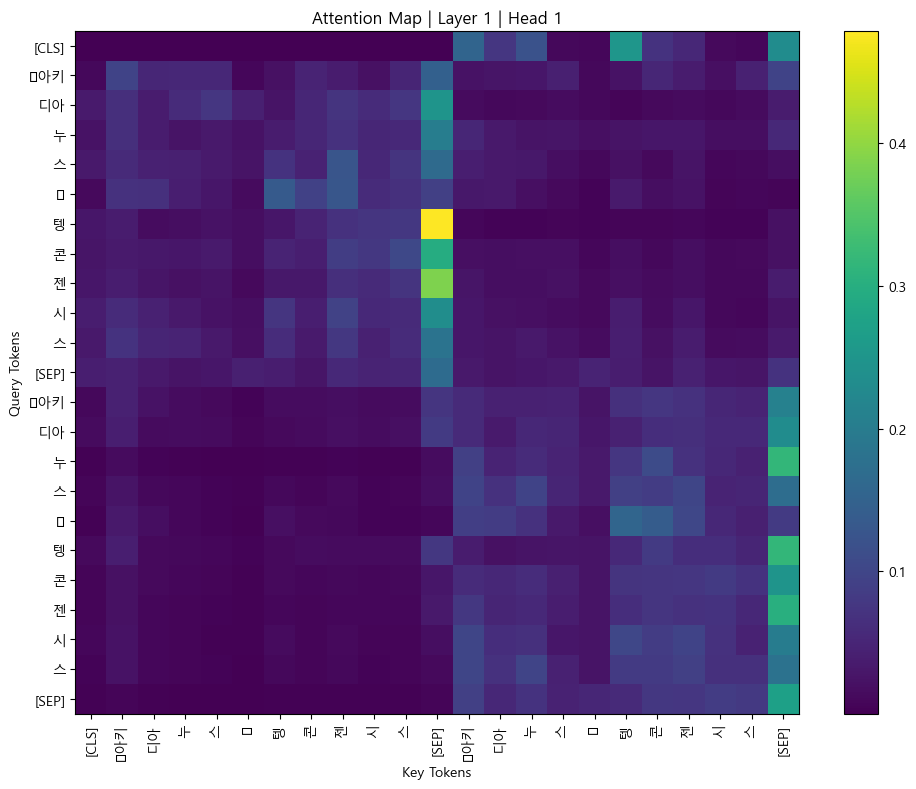

In [90]:
# ============================================================
# [STEP 9 - CELL 4] test sample attention map 출력
# - test 데이터 첫 샘플을 사용해서 attention map을 확인합니다.
# - 필요하면 layer_idx, head_idx를 바꿔 여러 장을 볼 수 있습니다.
# ============================================================

sample_idx = 0

sample_enc_tokens = test_inputs_t[0][sample_idx]
sample_segments = test_inputs_t[1][sample_idx]

plot_attention_map(
    model=pre_train_model,
    sample_enc_tokens=sample_enc_tokens,
    sample_segments=sample_segments,
    vocab=vocab,
    layer_idx=0,
    head_idx=0
)

### Step 10. 학습 결과 시각화 및 저장 파일 점검
- Total loss 시각화
- Train / Val NSP loss 시각화
- Train / Val MLM loss 시각화
- Train / Val NSP accuracy 시각화
- Train / Val MLM accuracy 시각화
- learning rate 시각화
- 저장된 모델 및 파일 확인
- 최종 train / val / test 결과 요약 출력

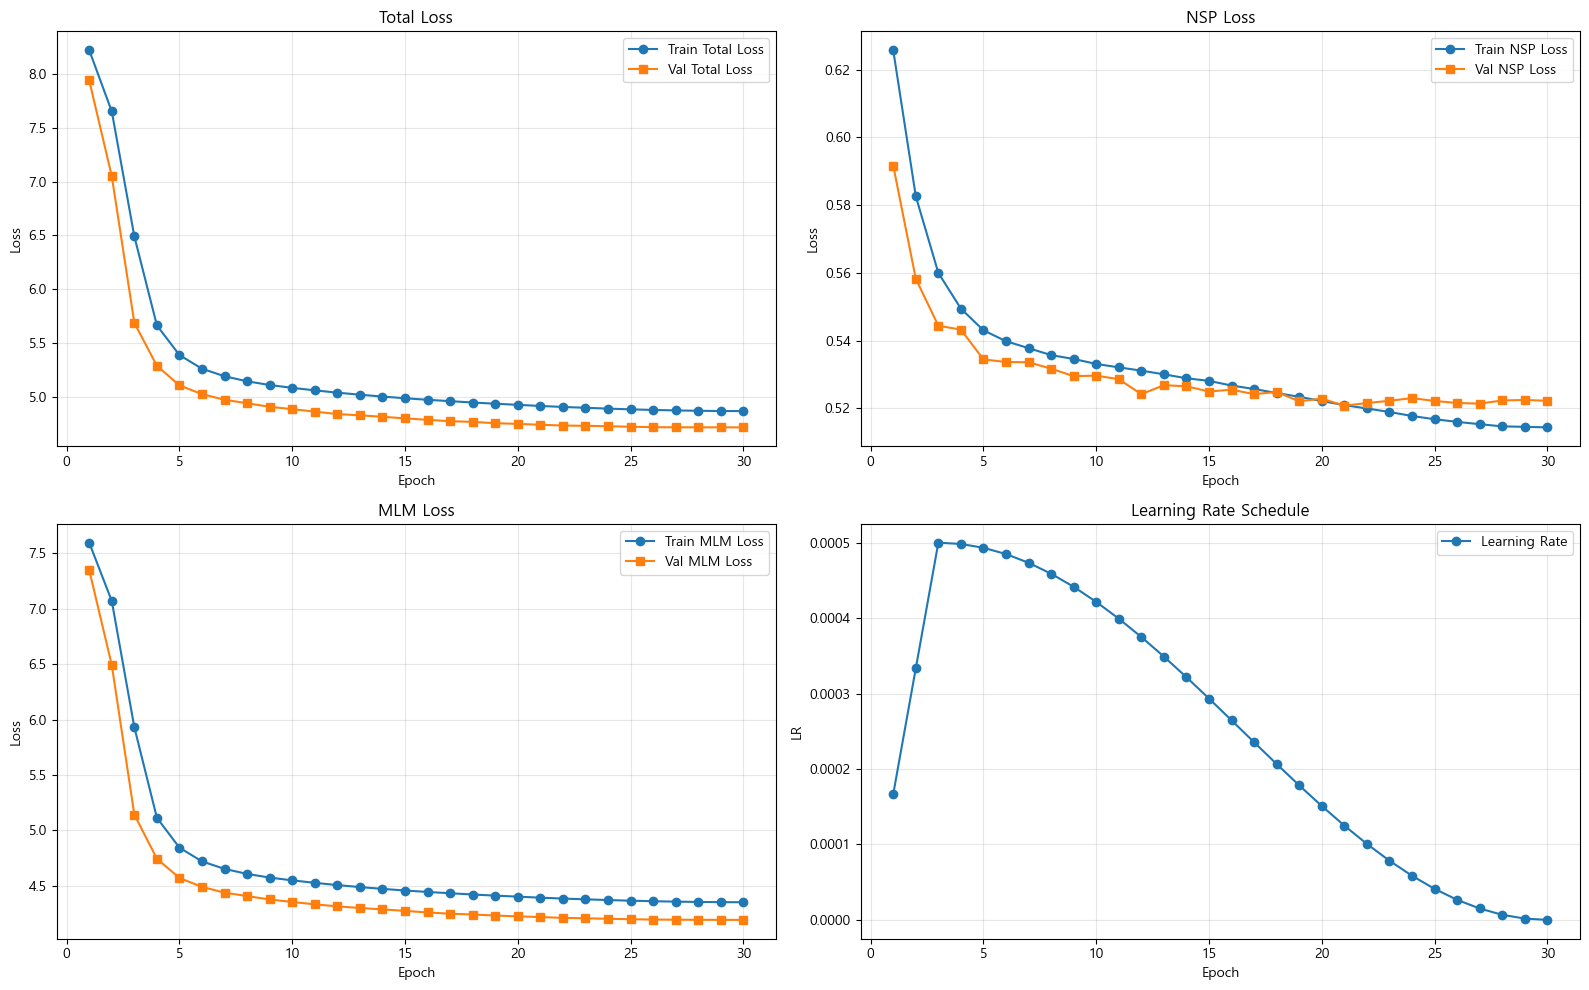

In [92]:
# ============================================================
# [STEP 10 - CELL 1] train / val loss 시각화
# - total loss, NSP loss, MLM loss를 train / val로 나누어 그립니다.
# - early stopping이 잘 작동했는지 경향을 함께 확인할 수 있습니다.
# ============================================================

epochs_range = range(1, len(history["train_total_loss"]) + 1)

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(epochs_range, history["train_total_loss"], marker="o", label="Train Total Loss")
plt.plot(epochs_range, history["val_total_loss"], marker="s", label="Val Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(epochs_range, history["train_nsp_loss"], marker="o", label="Train NSP Loss")
plt.plot(epochs_range, history["val_nsp_loss"], marker="s", label="Val NSP Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NSP Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(epochs_range, history["train_mlm_loss"], marker="o", label="Train MLM Loss")
plt.plot(epochs_range, history["val_mlm_loss"], marker="s", label="Val MLM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLM Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(epochs_range, history["lr"], marker="o", label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

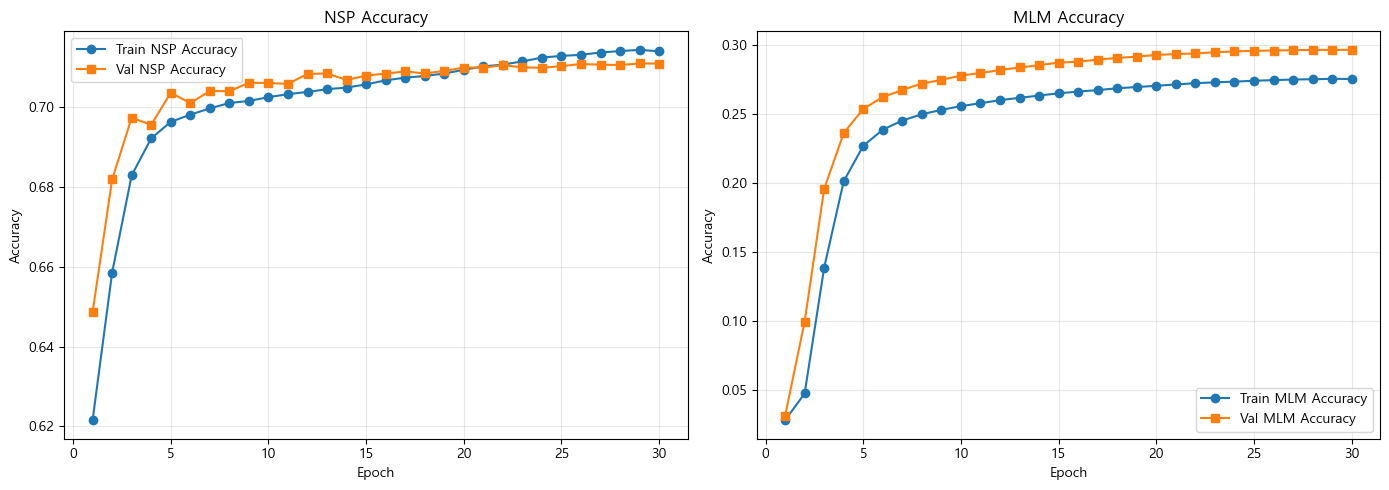

In [93]:
# ============================================================
# [STEP 10 - CELL 2] train / val accuracy 시각화
# - NSP accuracy와 MLM accuracy를 train / val로 나누어 시각화합니다.
# ============================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_nsp_acc"], marker="o", label="Train NSP Accuracy")
plt.plot(epochs_range, history["val_nsp_acc"], marker="s", label="Val NSP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("NSP Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_mlm_acc"], marker="o", label="Train MLM Accuracy")
plt.plot(epochs_range, history["val_mlm_acc"], marker="s", label="Val MLM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLM Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
# ============================================================
# [STEP 10 - CELL 3] 저장 파일 확인
# - mini_ 접두사로 저장된 파일들이 정상 생성되었는지 확인합니다.
# ============================================================

saved_files = [
    SPM_MODEL_PATH,
    SPM_VOCAB_PATH,
    PRETRAIN_JSON_PATH,
    MEMMAP_INFO_PATH,
    SPLIT_INDEX_PATH,
    MINI_CONFIG_PATH,
    MINI_HISTORY_PATH,
    MINI_BEST_MODEL_PATH,
    MINI_LAST_MODEL_PATH,
]

print("===== saved files =====")
for path in saved_files:
    print(path, "->", os.path.exists(path))

print("\n===== epoch checkpoints =====")
for epoch in range(1, EPOCHS + 1):
    ckpt = get_checkpoint_path(epoch)
    print(ckpt, "->", os.path.exists(ckpt))

===== saved files =====
models/mini_ko_8000.model -> True
models/mini_ko_8000.vocab -> True
data/mini_bert_pre_train.json -> True
data/mini_pretrain_memmap_info.json -> True
data/mini_split_indices.npz -> True
models/mini_bert_config.json -> True
models/mini_bert_history.json -> True
models/mini_bert_best.pt -> True
models/mini_bert_last.pt -> True

===== epoch checkpoints =====
models/mini_bert_epoch_01.pt -> True
models/mini_bert_epoch_02.pt -> True
models/mini_bert_epoch_03.pt -> True
models/mini_bert_epoch_04.pt -> True
models/mini_bert_epoch_05.pt -> True
models/mini_bert_epoch_06.pt -> True
models/mini_bert_epoch_07.pt -> True
models/mini_bert_epoch_08.pt -> True
models/mini_bert_epoch_09.pt -> True
models/mini_bert_epoch_10.pt -> True
models/mini_bert_epoch_11.pt -> True
models/mini_bert_epoch_12.pt -> True
models/mini_bert_epoch_13.pt -> True
models/mini_bert_epoch_14.pt -> True
models/mini_bert_epoch_15.pt -> True
models/mini_bert_epoch_16.pt -> True
models/mini_bert_epoch_17.

In [95]:
# ============================================================
# [STEP 10 - CELL 4] 최종 요약 출력
# - train / val / test 성능을 한 번에 보기 위한 요약 셀입니다.
# ============================================================

print("===== FINAL SUMMARY =====")
print(f"Total Params : {total_params:,}")
print(f"Best Epoch   : {best_epoch}")
print(f"Best Val Loss: {best_val_loss:.4f}")

print("\n[Last Train]")
print(f"train_total_loss: {history['train_total_loss'][-1]:.4f}")
print(f"train_nsp_loss  : {history['train_nsp_loss'][-1]:.4f}")
print(f"train_mlm_loss  : {history['train_mlm_loss'][-1]:.4f}")
print(f"train_nsp_acc   : {history['train_nsp_acc'][-1]:.4f}")
print(f"train_mlm_acc   : {history['train_mlm_acc'][-1]:.4f}")

print("\n[Last Val]")
print(f"val_total_loss  : {history['val_total_loss'][-1]:.4f}")
print(f"val_nsp_loss    : {history['val_nsp_loss'][-1]:.4f}")
print(f"val_mlm_loss    : {history['val_mlm_loss'][-1]:.4f}")
print(f"val_nsp_acc     : {history['val_nsp_acc'][-1]:.4f}")
print(f"val_mlm_acc     : {history['val_mlm_acc'][-1]:.4f}")

print("\n[Test]")
print(f"test_total_loss : {test_result['total_loss']:.4f}")
print(f"test_nsp_loss   : {test_result['nsp_loss']:.4f}")
print(f"test_mlm_loss   : {test_result['mlm_loss']:.4f}")
print(f"test_nsp_acc    : {test_result['nsp_acc']:.4f}")
print(f"test_mlm_acc    : {test_result['mlm_acc']:.4f}")

===== FINAL SUMMARY =====
Total Params : 1,023,842
Best Epoch   : 30
Best Val Loss: 4.7162

[Last Train]
train_total_loss: 4.8673
train_nsp_loss  : 0.5143
train_mlm_loss  : 4.3530
train_nsp_acc   : 0.7139
train_mlm_acc   : 0.2752

[Last Val]
val_total_loss  : 4.7162
val_nsp_loss    : 0.5222
val_mlm_loss    : 4.1940
val_nsp_acc     : 0.7108
val_mlm_acc     : 0.2964

[Test]
test_total_loss : 4.7159
test_nsp_loss   : 0.5219
test_mlm_loss   : 4.1940
test_nsp_acc    : 0.7110
test_mlm_acc    : 0.2966


### Step 11. mini-BERT 추론(Inference) 및 예측 결과 확인
- 학습된 best mini-BERT 모델 로드
- 추론용 입력 전처리 함수 정의
- MLM (Masked Language Model) 예측 수행
- NSP (Next Sentence Prediction) 예측 수행
- 예시 문장을 통한 추론 결과 확인
- 사용자 입력 문장을 통한 자유 추론 테스트
- mini-BERT 추론 결과 해석

In [105]:
# ============================================================
# [Step 11 - INFERENCE - CELL 1] best mini-BERT 모델 로드
# - 학습이 끝난 best checkpoint를 불러옵니다.
# - 기존에 정의된 config, PreTrainModel, vocab, device를 그대로 사용합니다.
# ============================================================

import torch
import torch.nn.functional as F

# best model checkpoint 로드
best_checkpoint = torch.load(MINI_BEST_MODEL_PATH, map_location=device)

# 모델 생성 및 weight 로드
infer_model = build_model_pre_train(config).to(device)
infer_model.load_state_dict(best_checkpoint["model_state_dict"])
infer_model.eval()

print("best model loaded from:", MINI_BEST_MODEL_PATH)
print("loaded epoch:", best_checkpoint.get("epoch", "unknown"))

best model loaded from: models/mini_bert_best.pt
loaded epoch: 30


In [107]:
# ============================================================
# [Step 11 - INFERENCE - CELL 2] 추론용 전처리 함수
# - MLM / NSP 입력을 mini-BERT 형식으로 바꿉니다.
# - [CLS], [SEP], segment, padding을 포함해 최종 입력 텐서를 생성합니다.
# ============================================================

def encode_text(text, vocab):
    """
    일반 문장을 SentencePiece token list로 변환
    """
    return vocab.encode_as_pieces(text)


def make_mlm_input(sentence, vocab, n_seq):
    """
    MLM 추론용 입력 생성
    예: '나는 [MASK] 먹었다'
    """
    # [MASK]는 직접 유지하고, 나머지 부분만 SentencePiece로 분해
    parts = sentence.split("[MASK]")
    tokens = []

    for i, part in enumerate(parts):
        part = part.strip()
        if part:
            tokens.extend(vocab.encode_as_pieces(part))
        if i < len(parts) - 1:
            tokens.append("[MASK]")

    tokens = ["[CLS]"] + tokens + ["[SEP]"]
    segment = [0] * len(tokens)

    if len(tokens) > n_seq:
        tokens = tokens[:n_seq-1] + ["[SEP]"]
        segment = segment[:n_seq]

    input_ids = [vocab.piece_to_id(tok) for tok in tokens]
    input_ids += [PAD_ID] * (n_seq - len(input_ids))

    segment += [0] * (n_seq - len(segment))

    return {
        "tokens": tokens,
        "input_ids": input_ids,
        "segment_ids": segment
    }


def make_nsp_input(sentence_a, sentence_b, vocab, n_seq):
    """
    NSP 추론용 입력 생성
    [CLS] sentence_a [SEP] sentence_b [SEP]
    """
    tokens_a = encode_text(sentence_a, vocab)
    tokens_b = encode_text(sentence_b, vocab)

    max_seq = n_seq - 3
    trim_tokens(tokens_a, tokens_b, max_seq)

    tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
    segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    input_ids = [vocab.piece_to_id(tok) for tok in tokens]
    input_ids += [PAD_ID] * (n_seq - len(input_ids))

    segment += [0] * (n_seq - len(segment))

    return {
        "tokens": tokens,
        "input_ids": input_ids,
        "segment_ids": segment
    }


def ids_to_pieces(id_list, vocab):
    """
    token id -> piece 문자열
    """
    return [vocab.id_to_piece(int(idx)) for idx in id_list]

In [109]:
# ============================================================
# [Step 11 - INFERENCE - CELL 3] MLM 추론 함수
# - [MASK] 위치의 상위 예측 토큰을 출력합니다.
# - top_k 개수만큼 후보를 보여줍니다.
# ============================================================

def predict_mlm(sentence_with_mask, model, vocab, config, top_k=10):
    """
    sentence_with_mask 예:
    '나는 [MASK] 먹었다'
    """
    model.eval()

    encoded = make_mlm_input(sentence_with_mask, vocab, config.n_seq)

    input_ids = torch.tensor([encoded["input_ids"]], dtype=torch.long).to(device)
    segment_ids = torch.tensor([encoded["segment_ids"]], dtype=torch.long).to(device)

    with torch.no_grad():
        logits_nsp, logits_mlm = model(input_ids, segment_ids)

    mask_positions = [i for i, tok in enumerate(encoded["tokens"]) if tok == "[MASK]"]

    if len(mask_positions) == 0:
        print("입력 문장에 [MASK]가 없습니다.")
        return

    print("입력 문장:", sentence_with_mask)
    print("토큰 시퀀스:", encoded["tokens"])
    print("-" * 60)

    for pos in mask_positions:
        probs = F.softmax(logits_mlm[0, pos], dim=-1)
        top_probs, top_ids = torch.topk(probs, k=top_k)

        print(f"[MASK] 위치 index = {pos}")
        for rank, (prob, idx) in enumerate(zip(top_probs.cpu().numpy(), top_ids.cpu().numpy()), start=1):
            piece = vocab.id_to_piece(int(idx))
            print(f"{rank:2d}. {piece:15s}  prob={prob:.4f}")
        print("-" * 60)

In [111]:
# ============================================================
# [Step 11 - INFERENCE - CELL 4] NSP 추론 함수
# - 두 문장이 이어지는 관계인지 확률로 출력합니다.
# - class 0: NotNext / class 1: IsNext 로 해석합니다.
# ============================================================

def predict_nsp(sentence_a, sentence_b, model, vocab, config):
    model.eval()

    encoded = make_nsp_input(sentence_a, sentence_b, vocab, config.n_seq)

    input_ids = torch.tensor([encoded["input_ids"]], dtype=torch.long).to(device)
    segment_ids = torch.tensor([encoded["segment_ids"]], dtype=torch.long).to(device)

    with torch.no_grad():
        logits_nsp, logits_mlm = model(input_ids, segment_ids)

    probs = F.softmax(logits_nsp[0], dim=-1).cpu().numpy()
    pred = int(np.argmax(probs))

    label_map = {
        0: "NotNext",
        1: "IsNext"
    }

    print("문장 A:", sentence_a)
    print("문장 B:", sentence_b)
    print("토큰 시퀀스:", encoded["tokens"])
    print("-" * 60)
    print(f"예측 결과      : {label_map[pred]}")
    print(f"NotNext 확률   : {probs[0]:.4f}")
    print(f"IsNext 확률    : {probs[1]:.4f}")

In [113]:
# ============================================================
# [Step 11 - INFERENCE - CELL 5] MLM 예시 실행
# - [MASK]가 포함된 문장을 넣으면 mini-BERT가 후보 토큰을 예측합니다.
# - 문장을 바꿔가며 여러 번 테스트할 수 있습니다.
# ============================================================

predict_mlm(
    sentence_with_mask="나는 [MASK] 먹었다",
    model=infer_model,
    vocab=vocab,
    config=config,
    top_k=10
)

입력 문장: 나는 [MASK] 먹었다
토큰 시퀀스: ['[CLS]', '▁나', '는', '[MASK]', '▁먹', '었다', '[SEP]']
------------------------------------------------------------
[MASK] 위치 index = 3
 1. ▁사람을             prob=0.2498
 2. ▁것을              prob=0.1123
 3. ▁주로              prob=0.0894
 4. ▁말을              prob=0.0694
 5. ▁먹               prob=0.0553
 6. ▁등을              prob=0.0386
 7. ▁사람들이            prob=0.0334
 8. ▁사람이             prob=0.0244
 9. ▁많이              prob=0.0211
10. ▁일을              prob=0.0118
------------------------------------------------------------


In [115]:
# ============================================================
# [Step 11 - INFERENCE - CELL 6] NSP 예시 실행 (이어지는 문장처럼 보이는 경우)
# - 문장 A와 문장 B가 자연스럽게 이어지는지 확인합니다.
# ============================================================

predict_nsp(
    sentence_a="나는 밥을 먹었다.",
    sentence_b="그래서 배가 불렀다.",
    model=infer_model,
    vocab=vocab,
    config=config
)

문장 A: 나는 밥을 먹었다.
문장 B: 그래서 배가 불렀다.
토큰 시퀀스: ['[CLS]', '▁나', '는', '▁', '밥', '을', '▁먹', '었다', '.', '[SEP]', '▁그래서', '▁배', '가', '▁불', '렀다', '.', '[SEP]']
------------------------------------------------------------
예측 결과      : NotNext
NotNext 확률   : 0.8227
IsNext 확률    : 0.1773


In [117]:
# ============================================================
# [Step 11 - INFERENCE - CELL 7] NSP 예시 실행 (관계 없는 문장처럼 보이는 경우)
# - 문장 A와 문장 B가 이어지지 않는 경우를 확인합니다.
# ============================================================

predict_nsp(
    sentence_a="나는 밥을 먹었다.",
    sentence_b="오늘 주식 시장이 상승했다.",
    model=infer_model,
    vocab=vocab,
    config=config
)

문장 A: 나는 밥을 먹었다.
문장 B: 오늘 주식 시장이 상승했다.
토큰 시퀀스: ['[CLS]', '▁나', '는', '▁', '밥', '을', '▁먹', '었다', '.', '[SEP]', '▁오늘', '▁주', '식', '▁시', '장이', '▁상', '승', '했다', '.', '[SEP]']
------------------------------------------------------------
예측 결과      : NotNext
NotNext 확률   : 0.6607
IsNext 확률    : 0.3393


In [119]:
# ============================================================
# [Step 11 - INFERENCE - CELL 8] 자유 입력 테스트 셀
# - 아래 문장만 바꿔서 바로 테스트할 수 있습니다.
# - MLM 또는 NSP 중 필요한 부분만 실행하면 됩니다.
# ============================================================

# -----------------------------
# MLM 자유 입력
# -----------------------------
user_mlm_sentence = "서울은 대한민국의 [MASK] 이다"

predict_mlm(
    sentence_with_mask=user_mlm_sentence,
    model=infer_model,
    vocab=vocab,
    config=config,
    top_k=10
)

# -----------------------------
# NSP 자유 입력
# -----------------------------
user_sentence_a = "서울은 대한민국의 수도이다."
user_sentence_b = "인구는 약 천만 명이다."

predict_nsp(
    sentence_a=user_sentence_a,
    sentence_b=user_sentence_b,
    model=infer_model,
    vocab=vocab,
    config=config
)

입력 문장: 서울은 대한민국의 [MASK] 이다
토큰 시퀀스: ['[CLS]', '▁서울', '은', '▁대한민국의', '[MASK]', '▁이', '다', '[SEP]']
------------------------------------------------------------
[MASK] 위치 index = 4
 1. ▁남자              prob=0.2408
 2. ▁여자              prob=0.1448
 3. ▁소설              prob=0.0715
 4. ▁작가              prob=0.0642
 5. ▁배우이다            prob=0.0434
 6. ▁가수              prob=0.0281
 7. ▁영화              prob=0.0262
 8. ▁선수              prob=0.0155
 9. ▁역사              prob=0.0152
10. ▁여성              prob=0.0120
------------------------------------------------------------
문장 A: 서울은 대한민국의 수도이다.
문장 B: 인구는 약 천만 명이다.
토큰 시퀀스: ['[CLS]', '▁서울', '은', '▁대한민국의', '▁수도', '이다', '.', '[SEP]', '▁인구는', '▁약', '▁천', '만', '▁명', '이다', '.', '[SEP]']
------------------------------------------------------------
예측 결과      : NotNext
NotNext 확률   : 0.7020
IsNext 확률    : 0.2980
